# Nonparametric Quality Control Charts
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Introduction](#introduction)
2. [Bakir & Reynolds' Wilcoxon Signed-Rank CUSUM](#bakir--reynolds-wilcoxon-signed-rank-cusum)
3. [Choosing $k$ and $h$](#choosing-k-and-h)
4. [Worked Example: Dentist Patient Retention](#worked-example-dentist-patient-retention)
5. [Worked Example: Coffee Satisfaction (Ordinal Data)](#worked-example-coffee-satisfaction-ordinal-data)
6. [Final Remarks](#final-remarks)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture (update the folder name to match your repo):

setwd("Slides//Week-12-Intro-to-NPSPC")

## Introduction

All semester, we've stressed how important it is to check a control chart's assumptions during Phase I before rolling it out for Phase II monitoring. As we saw in the last notebook, violating a hypothesis test's (and resultingly a control chart's) distributional assumption doesn't just cause a minor inconvenience, it can seriously degrade statistical power and inflate the false alarm rate, and it undermines any process capability analysis built on top of it. We spend a lot of time on assumption *checking*, but comparatively less time on what to actually do when those assumptions fail.

So: if a control chart's distributional assumption isn't met, what do we do? Fortunately, researchers have developed **nonparametric** (sometimes called *distribution-free*) control charting methods for exactly this situation. This can occur either when the assumption genuinely fails, or when it simply can't be verified (say, we don't have enough historical data to check it in the first place).

For a thorough treatment of this area, the [Chakraborti and Graham](https://www.wiley.com/en-us/shop/general-introductory-statistics/nonparametric-statistical-process-control-p-9781118890578) text referenced in the syllabus is an excellent resource, along with a couple of great overview papers by Chakraborti ([2001](https://www.tandfonline.com/doi/abs/10.1080/00224065.2001.11980081) and [2019](https://www.tandfonline.com/doi/pdf/10.1080/08982112.2018.1549330?casa_token=rwbtnvNAxxwAAAAA:xcuGpxdr8EHuKPN9plreFZD6e_Ev4WDNTELst-XtlbAOBcuoEqafNfCdl_k-EeYk0qJNorpns5Z6uw)). Nonparametric SPC has advanced enormously over the past 25 years, both in the univariate and multivariate settings. Much of this is due to advances in computing. This topic could easily be its own full course. Today we'll focus on one classical nonparametric control chart, with two worked examples.

## Bakir & Reynolds' Wilcoxon Signed-Rank CUSUM

One of the very first Phase II nonparametric univariate control charts was proposed in 1979 by [Bakir & Reynolds](https://www.tandfonline.com/doi/abs/10.1080/00401706.1979.10489747?journalCode=utch20). As a note, Reynolds was actually Dr. VanBrackle's (one of our emeritus professors) dissertation advisor at Virginia Tech. This chart, and many developed after it, adapt classical nonparametric test statistics (like the WSRT from the last notebook) into a control charting framework.

Bakir & Reynolds proposed embedding the **Wilcoxon Signed-Rank** statistic (which tests the median, not the mean) into a CUSUM-style chart. We'll walk through their one-sided (upper) version. Note, a two-sided version exists as well, but follows the same core logic.

### Building the plotting statistic

Assume we know the process median, or have a solid estimate of it — call it $\tilde{\mu}_0$. At time $t$, we take a random sample of size $n$: $x_{1t}, x_{2t}, \dots, x_{nt}$.

We rank the **absolute values** of the observations in ascending order (smallest gets rank 1, and so on), denoting the rank of observation $i$ at time $t$ as $R_{it}$. We also need to know the *sign* of each observation relative to $\tilde{\mu}_0$:

$$ I(x_{it} > \tilde{\mu}_0) = \begin{cases} 1 & \text{if } x_{it} > \tilde{\mu}_0 \\ -1 & \text{if } x_{it} < \tilde{\mu}_0 \end{cases} $$

The signed-rank statistic at time $t$ is then:

$$ SR_t = \sum_{i=1}^{n} I(x_{it} > \tilde{\mu}_0)R_{it} $$

If the process is in control (i.e., $\tilde{\mu}_0$ really is the process median), we'd expect $SR_t \approx 0$. The farther $SR_t$ strays from 0 in either direction, the more evidence of a shifted median. This is just the ordinary WSRT statistic. The real innovation is turning it into a CUSUM.

### From a single statistic to a CUSUM

Bakir & Reynolds borrowed the "slack value" idea, $k$, directly from the tabular CUSUM we covered earlier in the semester. We take the difference between each $SR_t$ and $k$, and accumulate those deviations:

$$ T_t = \sum_{j=1}^{t}(SR_j - k) $$

The final plotting statistic for a one-sided, upper CUSUM takes the most recent $T_t$ and subtracts the minimum $T_t$ observed up to that point:

$$ P_t = T_t - \min(0,T_1,T_2,\dots,T_t) $$

If $P_t \geq h$, the process signals out of control — exactly the same decision rule as the ordinary CUSUM chart.

## Choosing $k$ and $h$

So how do we choose $k$ and $h$? It's a little different than the ordinary CUSUM, since the WSRT statistic's distribution depends on the sample size $n$ — there's no universal $K = |\mu_1-\mu_0|/2$ shortcut here. Bakir and Reynolds provide general guidance via reference tables in their original manuscript.

![K Values](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/0e4a88302c50d69bdffc6add5e4b65447619c71e/Slides/Week-11-Intro-to-NP-Statistics/k_values.JPG)

![h Values](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/0e4a88302c50d69bdffc6add5e4b65447619c71e/Slides/Week-11-Intro-to-NP-Statistics/h_values.JPG)

In general, $k$ should be set larger when you specifically want to protect against a larger shift. Once $k$ is chosen, $h$ is selected to hit a target $ARL_0$ (say 370 or 500). This is the same design philosophy as the ordinary CUSUM, just referencing a different table.

For example, if we're in the design phase and want $ARL_0 \approx 370$, the tables suggest a sample size of $n=6$, with $k=15$ and $h=6$. Let's put that to work.

## Worked Example: Dentist Patient Retention

Suppose we run a dentist's office. The general recommendation is a checkup every six months; if a new patient doesn't return within a year, we generally assume they've switched providers, lost insurance, or otherwise aren't coming back. Naturally, retaining patients matters for staying in business, paying off dental school loans, and paying staff.

Suppose we know that, on average, 50 new patients return within a year (about 4.17 per month), and that the median number of months between successive visits is about $\tilde{\mu}_0 \approx 2.89$. We want to monitor the time between successive visits for new patients.

From data collected two years ago, we take random samples of new patients of size $n=6$ from each of 52 weeks, and build Bakir & Reynolds' CUSUM using the chart parameters above ($k=15$, $h=6$). Data live in `dentist.xlsx`, measured in months.

In [3]:
## STAT 7110 Nonparametric Methods R Code ## 

library(tidyverse)
library(readxl)
library(qcc)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


  __ _  ___ ___ 
 / _  |/ __/ __|  Quality Control Charts and 
| (_| | (_| (__   Statistical Process Control
 \__  |\___\___|
    |_|           version 2.7
Type 'citation("qcc")' for citing this R package in publications.


Warning message:
package ‘qcc’ was built under R version 4.5.3 


### Read in the data and specify the target median

In [4]:
## Read in Data ##

dentist <- read_xlsx("dentist.xlsx")

dentist |>
  glimpse()

## Specify Median ##

mu0 <- 2.89

Rows: 52
Columns: 7
$ `Patient 1` <dbl> 0.7344, 1.0855, 3.1390, 5.9879, 2.3852, 0.8997, 8.7181, 3.7260, 0.5824, 1.2200, 7.0488, 4.9847, 6.4400, 3.0551, …
$ `Patient 2` <dbl> 2.0960, 6.8871, 4.1446, 4.2972, 6.8538, 1.9898, 0.7992, 4.1340, 0.5980, 4.3272, 6.3034, 3.3077, 1.0766, 2.7229, …
$ `Patient 3` <dbl> 10.9944, 8.9559, 10.4563, 9.8459, 1.8710, 0.0740, 5.6993, 3.9430, 3.5518, 0.8190, 4.2355, 1.8136, 0.9053, 8.3674…
$ `Patient 4` <dbl> 3.3862, 0.9155, 4.8131, 0.7588, 3.2724, 2.5288, 9.6061, 3.9770, 2.1832, 7.6461, 3.3637, 0.1507, 5.8941, 9.3192, …
$ `Patient 5` <dbl> 0.3155, 5.4912, 5.3108, 8.5232, 0.5612, 0.7895, 5.2765, 2.7222, 7.9488, 6.3490, 5.9478, 0.0136, 5.4167, 2.9989, …
$ `Patient 6` <dbl> 1.3742, 2.8319, 3.0853, 0.9262, 5.5489, 1.2097, 0.0886, 3.1323, 2.2423, 2.9515, 0.1521, 5.7849, 6.8832, 2.7763, …
$ Week        <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 3…


### Calculate the Wilcoxon Signed-Rank statistic for each week

For each week's sample of 6 patients, we compute row-wise ranks of the raw values, determine each observation's sign relative to $\tilde{\mu}_0$, and combine them into $SR_t$.

In [5]:
## Calculate Wilcoxon Signed Rank Test Statistic for Each Sample ##

## Compute Rowwise Ranks ##

ranks <- t(apply(dentist[,-7],1,rank))

## Determine Signs ##

signs <- t(apply(dentist[,-7],1,FUN=function(x){
  
  k <- ifelse(x > mu0,1,-1)
  
  return(sign(k))
  
}))

## Put them together to obtain WSRT! ##

sr <- rowSums(signs*ranks)

### Accumulate $T_t$ and calculate the plotting statistic $P_t$

In [6]:
## Calculate Tt's ##

k <- 15
h <- 6

subz <- sr - k

Tts <- cumsum(subz)

In [7]:
## Determine Pts ##

min_tts <- vector("double",length=nrow(dentist))

for(i in 1:nrow(dentist)){
  
  min_tts[i] <- min(0,Tts[1:i])
  
}

Pts <- Tts - min_tts

### Plot the chart

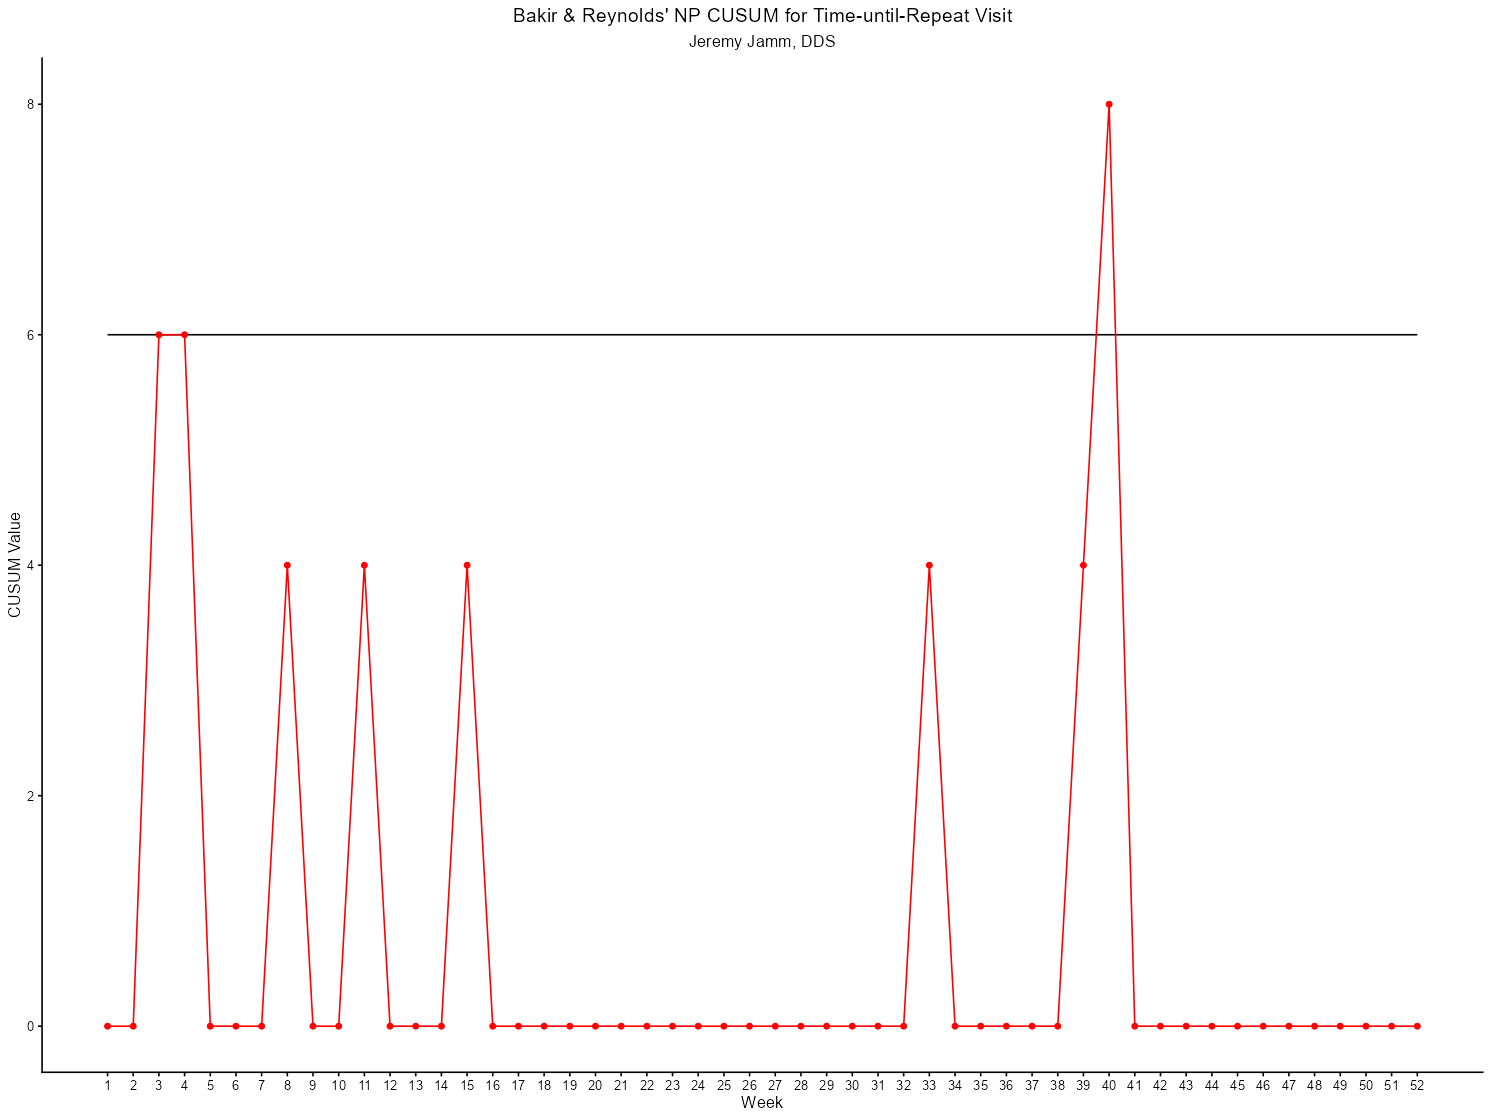

In [8]:
## Plot Chart ##

ggplot() + 
  geom_line(aes(x=seq(52),y=h),color="black") +
  geom_point(aes(x=seq(52),y=Pts),color="red") +
  geom_line(aes(x=seq(52),y=Pts),color="red") + 
  labs(x = "Week",
       y = "CUSUM Value") +
  theme_classic() +
  ggtitle("Bakir & Reynolds' NP CUSUM for Time-until-Repeat Visit",
          subtitle = "Jeremy Jamm, DDS") +
  theme(plot.title=element_text(hjust=0.50),
        plot.subtitle = element_text(hjust=0.50)) + 
  scale_x_continuous(breaks = seq(52))

### Identifying the out-of-control weeks and comparing to a Shewhart chart

Let's see exactly which weeks signaled out of control, and what the sample median looked like at those points.

In [9]:
## Okay, so let's determine which points are >= h and determine their medians ##

which(Pts >= h)

[1]  3  4 40

In [10]:
apply(dentist[which(Pts >= h),-7],1,median)

[1] 4.47885 5.14255 3.68855

In [11]:
mu0

[1] 2.89

Now let's see how a standard Shewhart $\bar{X}$/$R$ chart would have handled the exact same data.

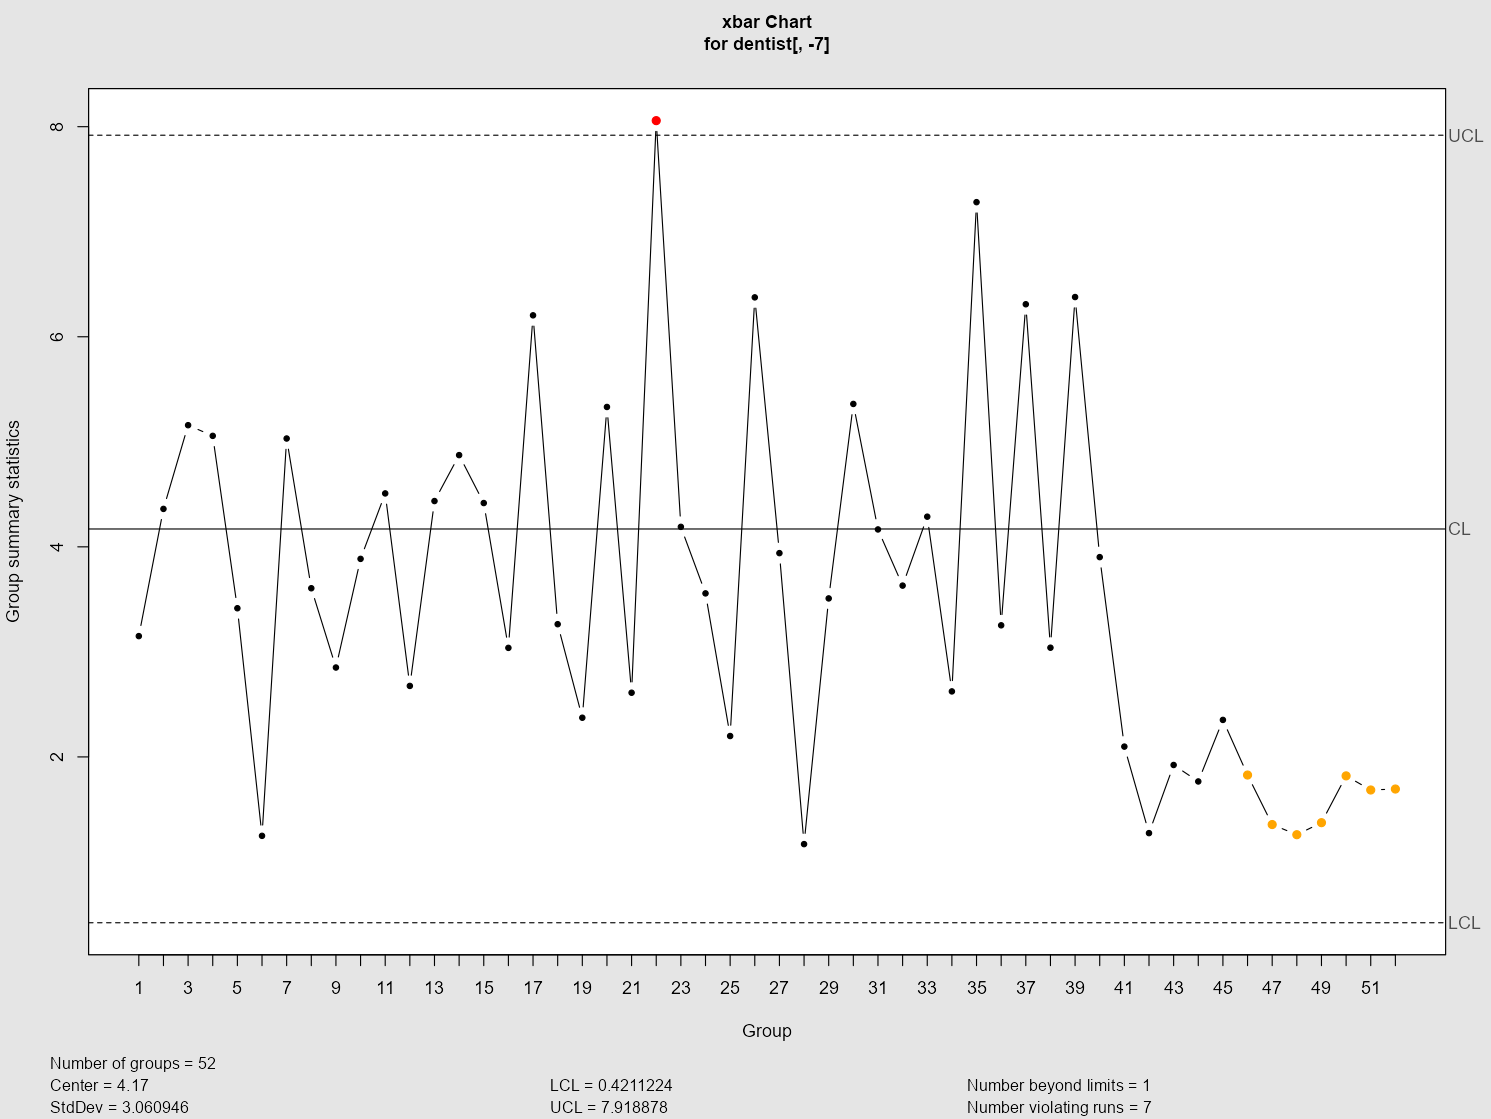

List of 11
 $ call      : language qcc(data = dentist[, -7], type = "xbar", center = 4.17, plot = T)
 $ type      : chr "xbar"
 $ data.name : chr "dentist[, -7]"
 $ data      : num [1:52, 1:6] 0.734 1.085 3.139 5.988 2.385 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:52] 3.15 4.36 5.16 5.06 3.42 ...
  ..- attr(*, "names")= chr [1:52] "1" "2" "3" "4" ...
 $ sizes     : int [1:52] 6 6 6 6 6 6 6 6 6 6 ...
 $ center    : num 4.17
 $ std.dev   : num 3.06
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0.421 7.919
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [12]:
## Let's compare to a Shewhart X-bar & R Chart ##

qcc(dentist[,-7],type="xbar",plot=T,center=4.17)

The difference is striking: Bakir & Reynolds' chart detected the shift at sample point 3, while the Shewhart chart took considerably longer to catch the same underlying change. This is the practical payoff of a nonparametric chart when the data don't cooperate with the usual normality assumption — faster detection, not just "a different way to get the same answer."

## Worked Example: Coffee Satisfaction (Ordinal Data)

Let's look at a different kind of data entirely. Suppose we're back at our familiar Dunkin' Donuts example, monitoring customer satisfaction with the coffee. For 30 consecutive days, we survey $n=6$ customers and ask them to rate their satisfaction on a 1 (very satisfied) to 5 (very dissatisfied) scale. This is an **ordinal**, discrete Likert-scale variable, not a continuous measurement.

If we find evidence the median satisfaction rating has exceeded 3.5 (remember, higher numbers mean *less* satisfaction), every employee gets sent to a weekend customer service training. Data live in `dunkin.xlsx`.

This kind of ordinal, non-continuous data is exactly the setting where nonparametric methods genuinely shine — a Shewhart chart's continuous-normal assumption was never a great fit for a 5-point rating scale to begin with.

### Read in the data and specify the target median

In [13]:
## Now let's look at an example using ordinal, Likert-scale items ##

## Read in Data ##

dunkin <- read_xlsx("dunkin.xlsx")

dunkin |>
  glimpse()

## Specify Median ##

mu0 <- 3

Rows: 30
Columns: 7
$ `Customer 1` <dbl> 1, 3, 1, 1, 2, 2, 3, 2, 2, 1, 4, 2, 2, 2, 3, 2, 4, 2, 1, 1, 1, 2, 1, 1, 2, 4, 2, 3, 3, 1
$ `Customer 2` <dbl> 1, 2, 1, 3, 3, 2, 1, 3, 1, 2, 2, 2, 1, 3, 1, 2, 1, 2, 2, 1, 1, 2, 3, 3, 1, 3, 1, 3, 2, 3
$ `Customer 3` <dbl> 3, 2, 1, 2, 2, 1, 3, 3, 1, 1, 2, 3, 3, 4, 2, 1, 1, 3, 1, 3, 3, 4, 2, 3, 2, 2, 2, 4, 2, 2
$ `Customer 4` <dbl> 1, 1, 1, 3, 1, 2, 3, 1, 3, 2, 4, 1, 2, 2, 2, 3, 2, 2, 1, 2, 3, 1, 2, 2, 1, 2, 2, 2, 2, 3
$ `Customer 5` <dbl> 2, 1, 3, 3, 3, 2, 1, 2, 2, 2, 3, 2, 1, 2, 2, 2, 1, 3, 2, 3, 1, 2, 1, 2, 2, 3, 2, 3, 2, 3
$ `Customer 6` <dbl> 3, 1, 1, 3, 3, 2, 1, 2, 2, 2, 3, 2, 2, 4, 5, 4, 2, 3, 2, 2, 2, 1, 1, 3, 4, 1, 1, 2, 3, 1
$ Day          <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30


### Calculate the WSR statistic, adapted for ordinal (tied) data

Two small differences from the dentist example: with integer-valued data, ties are common, so `rank()` assigns the *average* rank to tied values automatically. We'll also use $\geq$ instead of $>$ when determining signs, since we're working with a discrete variable where exact ties at the target are more likely.

In [14]:
## Calculate Wilcoxon Signed Rank Test Statistic for Each Sample ##

## Compute Rowwise Ranks ##

ranks <- t(apply(dunkin[,-7],1,rank))

## Notice, with integers, the average rank is assigned ##

## Determine Signs ##

## Notice here, we're going to add a >= since we are working
## with an ordinal (read, discrete) variable ##

signs <- t(apply(dunkin[,-7],1,FUN=function(x){
  
  k <- ifelse(x >= mu0,1,-1)
  
  return(sign(k))
  
}))

## Put them together to obtain WSRT! ##

sr <- rowSums(signs*ranks)

### Accumulate $T_t$ and calculate $P_t$ (note the different $k$, $h$ for this setting)

In [15]:
## Calculate Tt's ##

k <- 3
h <- 18

subz <- sr - k

Tts <- cumsum(subz)

In [16]:
## Determine Pts ##

min_tts <- vector("double",length=30)

for(i in 1:30){
  
  min_tts[i] <- min(0,Tts[1:i])
  
}

Pts <- Tts - min_tts

### Plot the chart

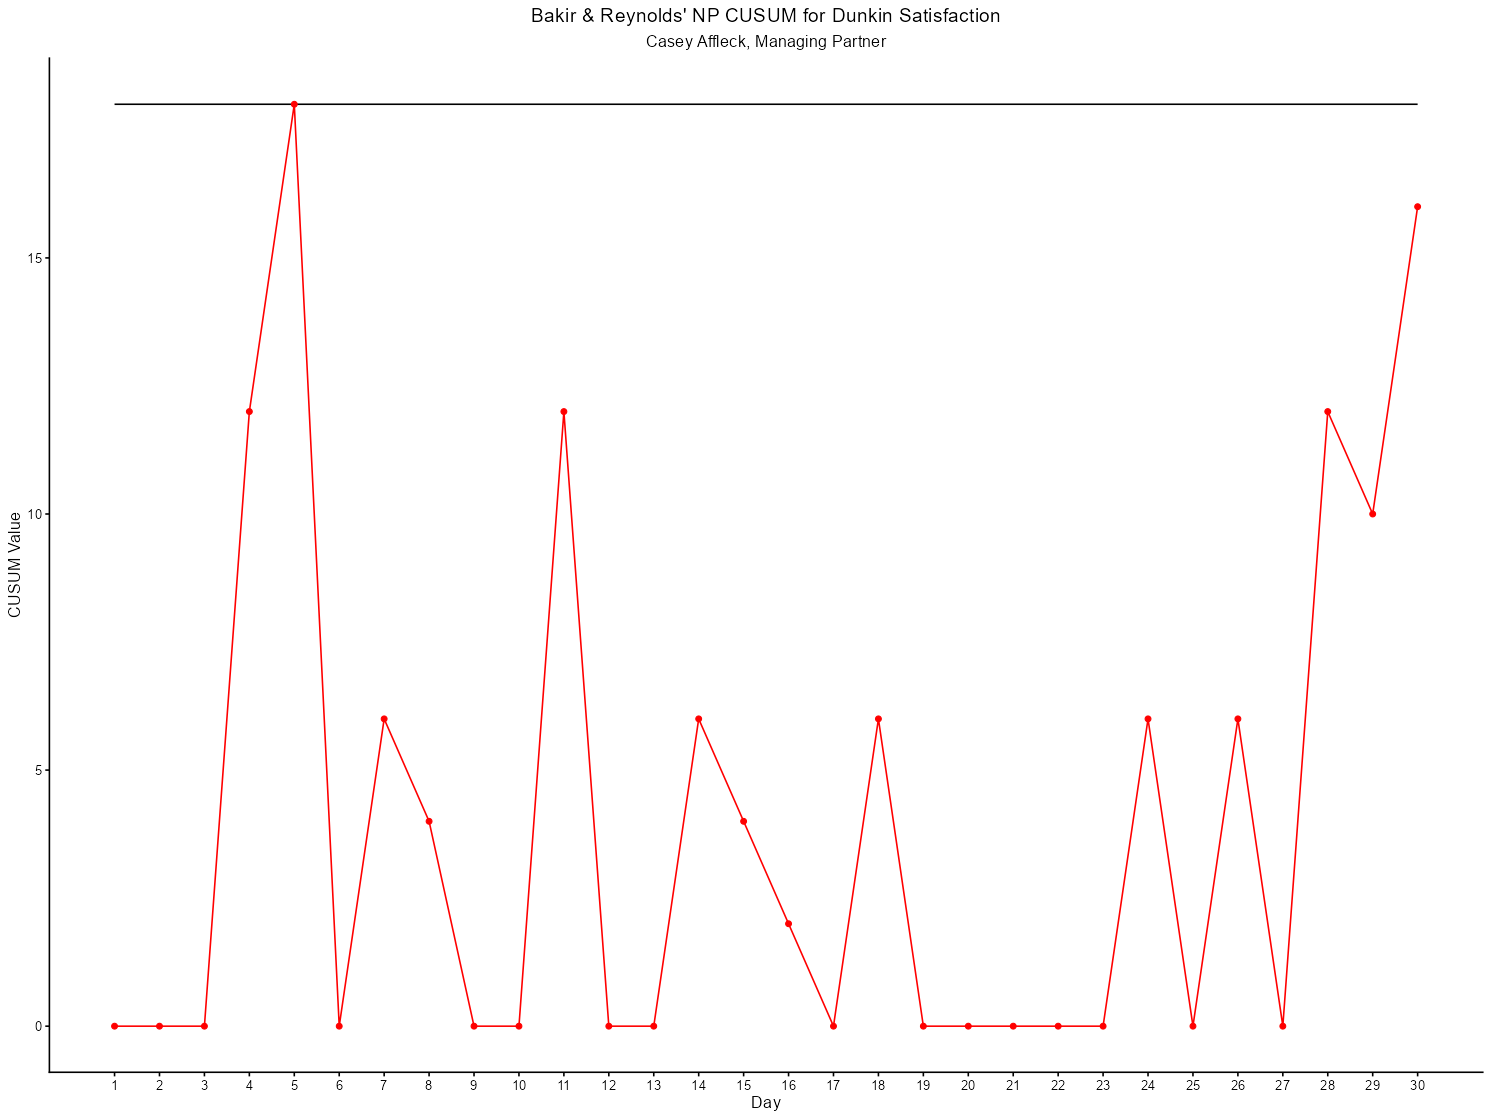

In [17]:
## Plot Chart ##

ggplot() + geom_line(aes(x=seq(30),y=h),color="black") +
  geom_point(aes(x=seq(30),y=Pts),color="red") +
  geom_line(aes(x=seq(30),y=Pts),color="red") + 
  labs(x = "Day",
       y = "CUSUM Value") +
  theme_classic() +
  ggtitle("Bakir & Reynolds' NP CUSUM for Dunkin Satisfaction",
          subtitle = "Casey Affleck, Managing Partner") +
  theme(plot.title=element_text(hjust=0.50),
        plot.subtitle = element_text(hjust=0.50)) + 
  scale_x_continuous(breaks = seq(30))

There's a point right around $t=5$ that looks like it might be signaling out of control. Let's check the day-by-day sample medians directly, and then compare against what a Shewhart chart concludes on the same data.

In [18]:
## An OOC point at t = 5? ## 

apply(dunkin[,-7],1,median)

 [1] 1.5 1.5 1.0 3.0 2.5 2.0 2.0 2.0 2.0 2.0 3.0 2.0 2.0 2.5 2.0 2.0 1.5 2.5 1.5 2.0 1.5 2.0 1.5 2.5 2.0 2.5 2.0 3.0 2.0 2.5

In [19]:
mu0

[1] 3

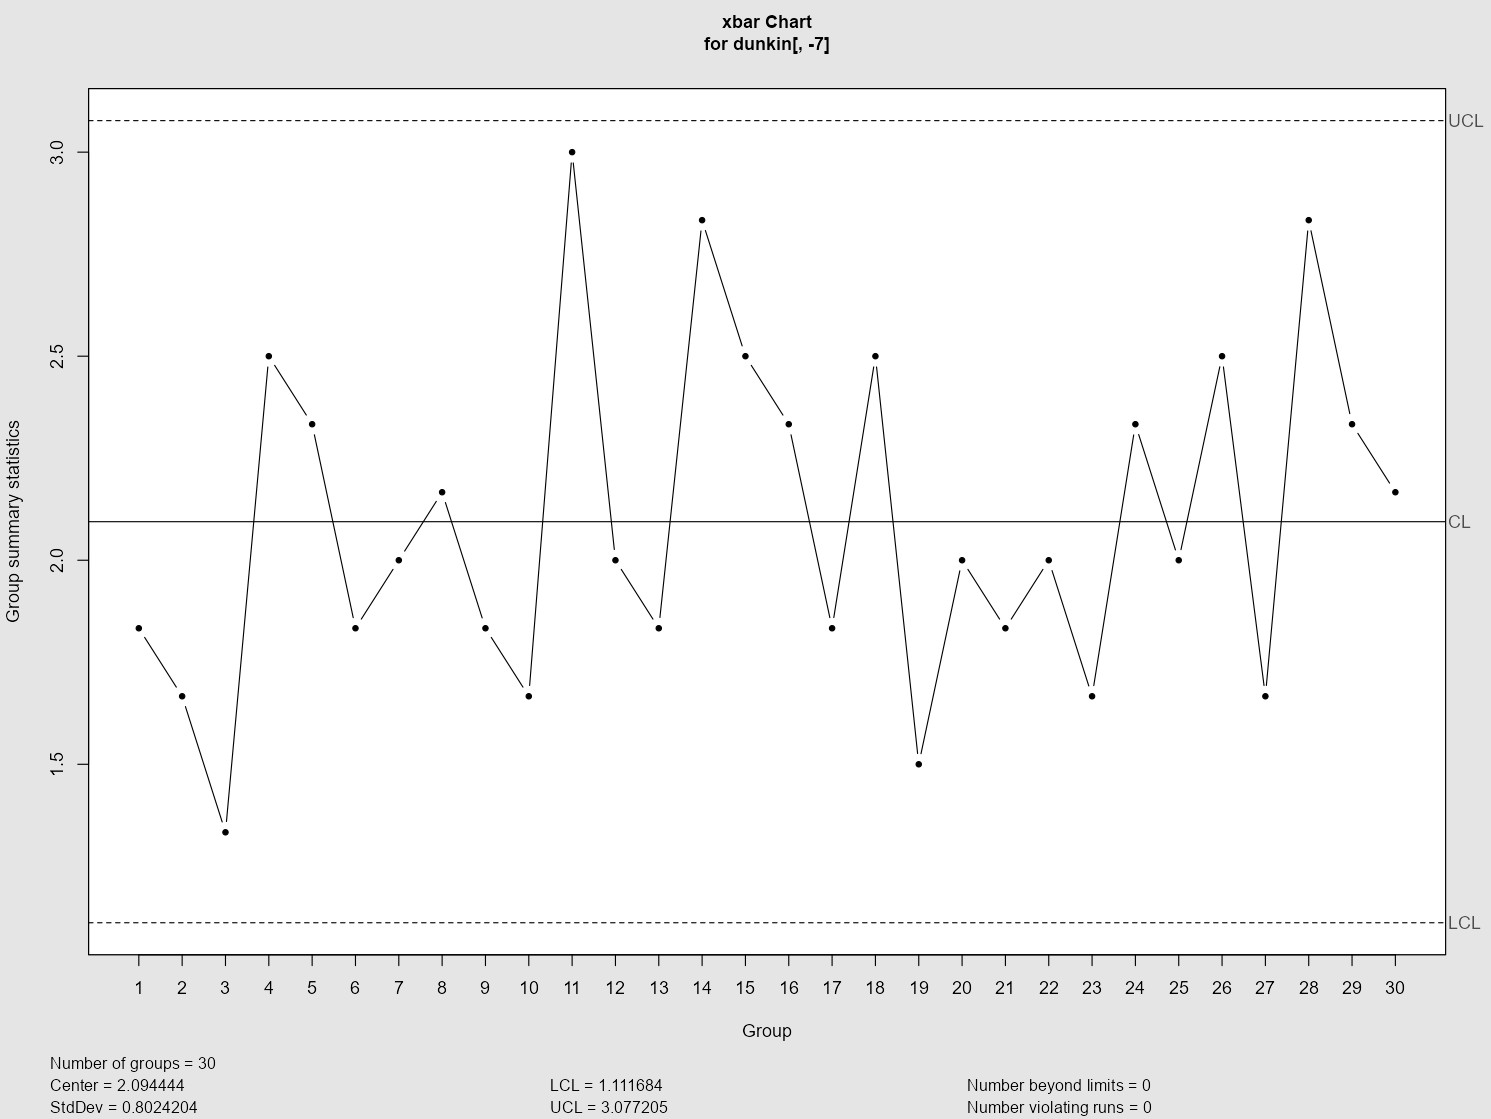

List of 11
 $ call      : language qcc(data = dunkin[, -7], type = "xbar", plot = T)
 $ type      : chr "xbar"
 $ data.name : chr "dunkin[, -7]"
 $ data      : num [1:30, 1:6] 1 3 1 1 2 2 3 2 2 1 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:30] 1.83 1.67 1.33 2.5 2.33 ...
  ..- attr(*, "names")= chr [1:30] "1" "2" "3" "4" ...
 $ sizes     : int [1:30] 6 6 6 6 6 6 6 6 6 6 ...
 $ center    : num 2.09
 $ std.dev   : num 0.802
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 1.11 3.08
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [21]:
## Let's compare to Shewhart ##

qcc(dunkin[,-7],type="xbar",plot=T)

Here's the interesting (and important) part: the Shewhart chart concludes the process is **in control**, while Bakir & Reynolds' chart concludes it's **out of control**. Which one should we trust?

**When a nonparametric test signals significance but the corresponding parametric test doesn't (or vice versa), it's generally best to trust the nonparametric result** — especially here, where the underlying data (a 5-point ordinal scale) never satisfied the Shewhart chart's continuous-normal assumption in the first place. The parametric chart isn't wrong because of a coding error; it's wrong because it was built on an assumption this data never met.

## Final Remarks

Both examples make the same point from two different angles: the dentist example showed a nonparametric chart detecting a real shift *faster* than its Shewhart counterpart, and the coffee example showed the two charts reaching outright **opposite** conclusions on data that was never a good fit for the parametric chart's assumptions to begin with.

Bakir & Reynolds' WSR CUSUM is just one entry point into a much larger area. Nonparametric SPC now spans univariate and multivariate methods, charts built on other rank-based and sign-based statistics, and — as referenced earlier — enough depth to fill an entire course on its own. If this is a topic you want to pursue further (particularly if you're a Ph.D. student looking for research directions), the Chakraborti and Graham text and the Chakraborti overview papers (2001, 2014, 2019) referenced at the start of this notebook are the right place to start.